# TimesFM v3.1 — XReg ablation and blend-stability audit

This notebook performs no TimesFM inference and no training. It downloads the v3 evaluation artifact from W&B, repeats the corrected clipping-aware weight search with and without XReg, and checks weight stability on time-ordered subfolds inside the 20-week calibration period. The untouched final 39-week validation is used only once for the final audit comparison.

In [1]:
%pip install -q -U wandb pandas numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 37.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.


In [2]:
import hashlib
import json
import platform
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb

print(
    {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "wandb": wandb.__version__,
    }
)

{'python': '3.12.13', 'pandas': '3.0.3', 'wandb': '0.28.0'}


In [3]:
CONFIG = {
    "output_dir": "/content/artifacts/timesfm_v3_1_audit",
    "v3_artifact": "timesfm-v3-xreg-corrected-calibration:latest",
    "weight_step": 0.05,
    "holiday_weight": 5.0,
    "clip_min": 0.0,
    "clip_max": 300000.0,
    "wandb_entity": "kende23-n-a",
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_run_name": "timesfm_v3_1_xreg_ablation_stability_audit",
    "seed": 42,
}
OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(CONFIG["seed"])
print(CONFIG)

{'output_dir': '/content/artifacts/timesfm_v3_1_audit', 'v3_artifact': 'timesfm-v3-xreg-corrected-calibration:latest', 'weight_step': 0.05, 'holiday_weight': 5.0, 'clip_min': 0.0, 'clip_max': 300000.0, 'wandb_entity': 'kende23-n-a', 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting', 'wandb_run_name': 'timesfm_v3_1_xreg_ablation_stability_audit', 'seed': 42}


In [4]:
try:
    from google.colab import userdata

    wandb_key = userdata.get("WANDB_API_KEY")
except Exception:
    wandb_key = None
wandb.login(key=wandb_key) if wandb_key else wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kende23 (kende23-n-a) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Download the exact v3 predictions from W&B

In [5]:
api = wandb.Api()
uri = f"{CONFIG['wandb_entity']}/{CONFIG['wandb_project']}/{CONFIG['v3_artifact']}"
artifact = api.artifact(uri)
artifact_dir = Path(artifact.download(root=str(OUTPUT_DIR / "v3_artifact")))
calibration = pd.read_csv(
    artifact_dir / "calibration_predictions.csv", parse_dates=["Date"]
)
validation = pd.read_csv(
    artifact_dir / "validation_predictions.csv", parse_dates=["Date"]
)
required = {
    "Weekly_Sales",
    "IsHoliday",
    "SeasonalNaive52",
    "TimesFM_Raw",
    "TimesFM_Residual",
    "TimesFM_XReg",
}
assert required.issubset(calibration.columns) and required.issubset(validation.columns)
print(
    {
        "artifact": artifact.name,
        "calibration_rows": len(calibration),
        "calibration_weeks": calibration.Date.nunique(),
        "validation_rows": len(validation),
        "validation_weeks": validation.Date.nunique(),
    }
)

wandb:   7 of 7 files downloaded.  


{'artifact': 'timesfm-v3-xreg-corrected-calibration:latest', 'calibration_rows': 59317, 'calibration_weeks': 20, 'validation_rows': 115588, 'validation_weeks': 39}


## Corrected simplex search

Every combination is clipped before WMAE. The function supports either the original three candidates or all four candidates including XReg.

In [6]:
def wmae(y, p, h):
    y, p = np.asarray(y, float), np.asarray(p, float)
    weights = np.where(np.asarray(h, bool), CONFIG["holiday_weight"], 1.0)
    return float(np.sum(weights * np.abs(y - p)) / np.sum(weights))


def compositions(total, parts, prefix=()):
    if parts == 1:
        yield prefix + (total,)
        return
    for value in range(total + 1):
        yield from compositions(total - value, parts - 1, prefix + (value,))


def materialize(frame, candidates, weights):
    pred = sum(
        float(w) * frame[name].to_numpy(float) for name, w in zip(candidates, weights)
    )
    return np.clip(pred, CONFIG["clip_min"], CONFIG["clip_max"])


def search_weights(frame, candidates):
    steps = int(round(1 / CONFIG["weight_step"]))
    rows = []
    for counts in compositions(steps, len(candidates)):
        weights = np.asarray(counts, float) / steps
        pred = materialize(frame, candidates, weights)
        rows.append(
            {
                **{f"w_{name}": float(w) for name, w in zip(candidates, weights)},
                "wmae": wmae(frame.Weekly_Sales, pred, frame.IsHoliday),
            }
        )
    table = pd.DataFrame(rows).sort_values("wmae").reset_index(drop=True)
    best = table.iloc[0]
    return np.asarray([best[f"w_{name}"] for name in candidates], float), table


THREE = ["SeasonalNaive52", "TimesFM_Raw", "TimesFM_Residual"]
FOUR = THREE + ["TimesFM_XReg"]

In [7]:
weights3, search3 = search_weights(calibration, THREE)
weights4, search4 = search_weights(calibration, FOUR)
calibration["Blend_No_XReg"] = materialize(calibration, THREE, weights3)
validation["Blend_No_XReg"] = materialize(validation, THREE, weights3)
calibration["Blend_With_XReg"] = materialize(calibration, FOUR, weights4)
validation["Blend_With_XReg"] = materialize(validation, FOUR, weights4)
assert np.isclose(
    wmae(calibration.Weekly_Sales, calibration.Blend_No_XReg, calibration.IsHoliday),
    search3.iloc[0].wmae,
    atol=1e-9,
)
assert np.isclose(
    wmae(calibration.Weekly_Sales, calibration.Blend_With_XReg, calibration.IsHoliday),
    search4.iloc[0].wmae,
    atol=1e-9,
)
ablation = pd.DataFrame(
    [
        {
            "setup": "corrected_no_xreg",
            "weights": dict(zip(THREE, weights3)),
            "calibration_wmae": search3.iloc[0].wmae,
            "validation_wmae": wmae(
                validation.Weekly_Sales, validation.Blend_No_XReg, validation.IsHoliday
            ),
        },
        {
            "setup": "corrected_with_xreg",
            "weights": dict(zip(FOUR, weights4)),
            "calibration_wmae": search4.iloc[0].wmae,
            "validation_wmae": wmae(
                validation.Weekly_Sales,
                validation.Blend_With_XReg,
                validation.IsHoliday,
            ),
        },
    ]
)
ablation["validation_gain_vs_no_xreg"] = (
    ablation.loc[0, "validation_wmae"] - ablation.validation_wmae
)
display(ablation)
print(
    {
        "no_xreg_weights": dict(zip(THREE, weights3)),
        "with_xreg_weights": dict(zip(FOUR, weights4)),
    }
)

,setup,weights,calibration_wmae,validation_wmae,validation_gain_vs_no_xreg
0,corrected_no_xreg,"{'SeasonalNaive52': 0.4, 'TimesFM_Raw': 0.1, '...",1933.874081,1615.971910,0.000000
1,corrected_with_xreg,"{'SeasonalNaive52': 0.4, 'TimesFM_Raw': 0.05, ...",1918.619354,1588.802945,27.168965


{'no_xreg_weights': {'SeasonalNaive52': np.float64(0.4), 'TimesFM_Raw': np.float64(0.1), 'TimesFM_Residual': np.float64(0.5)}, 'with_xreg_weights': {'SeasonalNaive52': np.float64(0.4), 'TimesFM_Raw': np.float64(0.05), 'TimesFM_Residual': np.float64(0.45), 'TimesFM_XReg': np.float64(0.1)}}


## Time-ordered stability audit

The 20 calibration weeks produce two expanding-window checks: weeks 1–10 select weights and weeks 11–15 evaluate them; then weeks 1–15 select weights and weeks 16–20 evaluate them. These folds diagnose whether XReg's contribution persists across time without touching final validation.

In [8]:
dates = np.asarray(sorted(calibration.Date.unique()))
fold_specs = [
    ("fold_1", dates[:10], dates[10:15]),
    ("fold_2", dates[:15], dates[15:20]),
]
fold_rows = []
for fold, train_dates, test_dates in fold_specs:
    fit = calibration[calibration.Date.isin(train_dates)]
    holdout = calibration[calibration.Date.isin(test_dates)]
    for label, candidates in [("no_xreg", THREE), ("with_xreg", FOUR)]:
        weights, table = search_weights(fit, candidates)
        pred = materialize(holdout, candidates, weights)
        fold_rows.append(
            {
                "fold": fold,
                "setup": label,
                "fit_start": str(pd.Timestamp(train_dates[0]).date()),
                "fit_end": str(pd.Timestamp(train_dates[-1]).date()),
                "holdout_start": str(pd.Timestamp(test_dates[0]).date()),
                "holdout_end": str(pd.Timestamp(test_dates[-1]).date()),
                "fit_wmae": table.iloc[0].wmae,
                "holdout_wmae": wmae(holdout.Weekly_Sales, pred, holdout.IsHoliday),
                **{f"w_{name}": float(w) for name, w in zip(candidates, weights)},
            }
        )
fold_results = pd.DataFrame(fold_rows)
display(fold_results)
fold_pivot = fold_results.pivot(
    index="fold", columns="setup", values="holdout_wmae"
).reset_index()
fold_pivot["xreg_gain"] = fold_pivot.no_xreg - fold_pivot.with_xreg
display(fold_pivot)

,fold,setup,fit_start,fit_end,holdout_start,holdout_end,fit_wmae,holdout_wmae,w_SeasonalNaive52,w_TimesFM_Raw,w_TimesFM_Residual,w_TimesFM_XReg
0,fold_1,no_xreg,2011-09-16,2011-11-18,2011-11-25,2011-12-23,1371.062954,3343.162569,0.15,0.4,0.45,NaN
1,fold_1,with_xreg,2011-09-16,2011-11-18,2011-11-25,2011-12-23,1344.486952,2978.697517,0.20,0.2,0.40,0.20
2,fold_2,no_xreg,2011-09-16,2011-12-23,2011-12-30,2012-01-27,1880.229536,2058.775486,0.30,0.1,0.60,NaN
3,fold_2,with_xreg,2011-09-16,2011-12-23,2011-12-30,2012-01-27,1854.625083,2071.024999,0.35,0.0,0.50,0.15


setup,fold,no_xreg,with_xreg,xreg_gain
0,fold_1,3343.162569,2978.697517,364.465053
1,fold_2,2058.775486,2071.024999,-12.249513


## Final audit summary and diagnostics

{'audit/no_xreg_validation_wmae': 1615.9719102039328, 'audit/with_xreg_validation_wmae': 1588.8029448973086, 'audit/xreg_validation_gain': 27.16896530662416, 'audit/xreg_relative_gain_pct': 1.6812770775944665, 'audit/xreg_helpful_temporal_folds': 1, 'audit/temporal_folds': 2}
{'prediction_sha256': '556efcd0202ded86e8cc8af53603fc4980a74df94485c57616b1cf5668b6ccab'}


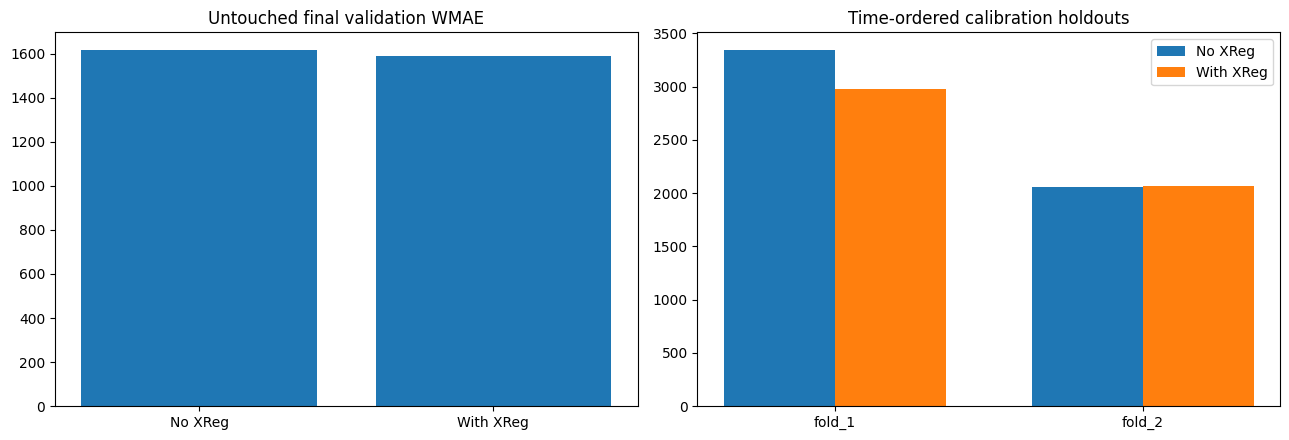

In [9]:
no_xreg_wmae = float(
    ablation.loc[ablation.setup == "corrected_no_xreg", "validation_wmae"].iloc[0]
)
with_xreg_wmae = float(
    ablation.loc[ablation.setup == "corrected_with_xreg", "validation_wmae"].iloc[0]
)
xreg_gain = no_xreg_wmae - with_xreg_wmae
stable_folds = int((fold_pivot.xreg_gain > 0).sum())
metrics = {
    "audit/no_xreg_validation_wmae": no_xreg_wmae,
    "audit/with_xreg_validation_wmae": with_xreg_wmae,
    "audit/xreg_validation_gain": xreg_gain,
    "audit/xreg_relative_gain_pct": 100 * xreg_gain / no_xreg_wmae,
    "audit/xreg_helpful_temporal_folds": stable_folds,
    "audit/temporal_folds": len(fold_pivot),
}
prediction_hash = hashlib.sha256(
    validation.Blend_With_XReg.to_numpy(np.float64).tobytes()
).hexdigest()
print(metrics)
print({"prediction_sha256": prediction_hash})
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(["No XReg", "With XReg"], [no_xreg_wmae, with_xreg_wmae])
axes[0].set_title("Untouched final validation WMAE")
x = np.arange(len(fold_pivot))
axes[1].bar(x - 0.18, fold_pivot.no_xreg, 0.36, label="No XReg")
axes[1].bar(x + 0.18, fold_pivot.with_xreg, 0.36, label="With XReg")
axes[1].set_xticks(x, fold_pivot.fold)
axes[1].set_title("Time-ordered calibration holdouts")
axes[1].legend()
plt.tight_layout()
plot_path = OUTPUT_DIR / "timesfm_v3_1_audit.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

## Log the audit to W&B

In [10]:
paths = {
    "ablation": OUTPUT_DIR / "ablation.csv",
    "folds": OUTPUT_DIR / "temporal_fold_results.csv",
    "search3": OUTPUT_DIR / "weight_search_no_xreg.csv",
    "search4": OUTPUT_DIR / "weight_search_with_xreg.csv",
    "validation": OUTPUT_DIR / "validation_audited_predictions.csv",
    "metrics": OUTPUT_DIR / "metrics.json",
}
ablation.assign(weights=ablation.weights.astype(str)).to_csv(
    paths["ablation"], index=False
)
fold_results.to_csv(paths["folds"], index=False)
search3.to_csv(paths["search3"], index=False)
search4.to_csv(paths["search4"], index=False)
validation.to_csv(paths["validation"], index=False)
manifest = {
    "experiment": "TimesFM v3.1 XReg ablation and stability audit",
    "source_artifact": artifact.name,
    "prediction_sha256": prediction_hash,
    **metrics,
}
paths["metrics"].write_text(json.dumps(manifest, indent=2))
run = wandb.init(
    entity=CONFIG["wandb_entity"],
    project=CONFIG["wandb_project"],
    group="timesfm-experiments",
    job_type="prediction_ablation_audit",
    name=CONFIG["wandb_run_name"],
    config=CONFIG,
)
run.log(metrics)
run.log(
    {
        "audit/ablation": wandb.Table(
            dataframe=ablation.assign(weights=ablation.weights.astype(str))
        ),
        "audit/temporal_folds": wandb.Table(dataframe=fold_results),
        "audit/plot": wandb.Image(str(plot_path)),
    }
)
out = wandb.Artifact(
    "timesfm-v3-1-xreg-ablation-audit", type="evaluation", metadata=manifest
)
for p in [*paths.values(), plot_path]:
    out.add_file(str(p))
run.log_artifact(out, aliases=["v3.1", "latest"])
run.summary.update(manifest)
run.finish()
print({"wandb_logged": True, "artifact": out.name, "output_dir": str(OUTPUT_DIR)})

audit/no_xreg_validation_wmae,▁
audit/temporal_folds,▁
audit/with_xreg_validation_wmae,▁
audit/xreg_helpful_temporal_folds,▁
audit/xreg_relative_gain_pct,▁
audit/xreg_validation_gain,▁
audit/no_xreg_validation_wmae,1615.97191
audit/temporal_folds,2
audit/with_xreg_validation_wmae,1588.80294
audit/xreg_helpful_temporal_folds,1
audit/xreg_relative_gain_pct,1.68128


{'wandb_logged': True, 'artifact': 'timesfm-v3-1-xreg-ablation-audit', 'output_dir': '/content/artifacts/timesfm_v3_1_audit'}


## Decision rule

Keep XReg in the next TimesFM blend only if it improves untouched final validation and does not consistently harm both time-ordered calibration holdouts. If the evidence is unstable, use the corrected no-XReg blend before LoRA fine-tuning.